In [ ]:
from shapely.geometry import shape
import json
import pandas as pd
import pandas as pd
import matplotlib.colors as mcolors
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import utils.analysis_functions as af

In [2]:
df=pd.read_csv('data/processed/PID_location_WSCI.csv')
csc_df=pd.read_csv('data/processed/csc/PID_csc_upsampled.csv')

In [3]:
df = df[df['WSCI'] >= -100]
df = df[df['lon'] <= 0]
df = df[df['lon'] >=-130]

df = df[df['lat'] >= 20]

In [4]:
csc_df.rename(columns={'PID_left':'PID'}, inplace=True)

In [5]:
total_df = pd.merge(df, csc_df, on='PID', how='inner')
total_df.dropna(subset=['WSCI', 'csc'], inplace=True)

In [6]:
total_df

,PID,lat,lon,BHAGE,managed,ownership,biome,WSCI,Unnamed: 0,csc
0,1_32_3_523_423,36.139489,-115.548198,NaN,0.0,national_forest,Xeric shrublands,9.278346,438,9.706334
1,1_32_3_521_423,36.139920,-115.662665,NaN,0.0,national_forest,Xeric shrublands,8.190137,469,9.794741
2,1_32_3_85010_1,36.154960,-115.589376,NaN,0.0,national_forest,Xeric shrublands,9.214615,503,9.837856
3,1_32_3_83788_1,36.158003,-115.640089,NaN,0.0,national_forest,Xeric shrublands,8.902037,528,9.708102
4,1_32_3_487_423,36.180257,-115.724253,NaN,0.0,national_forest,Xeric shrublands,8.195803,597,9.804961
...,...,...,...,...,...,...,...,...,...,...
187129,1_19_5_20135_1,43.482715,-91.472034,NaN,1.0,other,Temperate broadleaf forests,8.924268,23523432,10.813293
187130,1_19_5_6_301,43.490000,-91.530000,NaN,1.0,other,Temperate broadleaf forests,9.917923,23523667,10.563380
187131,1_19_5_12_301,43.490000,-91.420000,NaN,0.0,other,Temperate broadleaf forests,10.017304,23523713,10.826653
187132,1_19_5_20090_1,43.490491,-91.400523,NaN,0.0,other,Temperate broadleaf forests,9.925303,23523748,10.839954


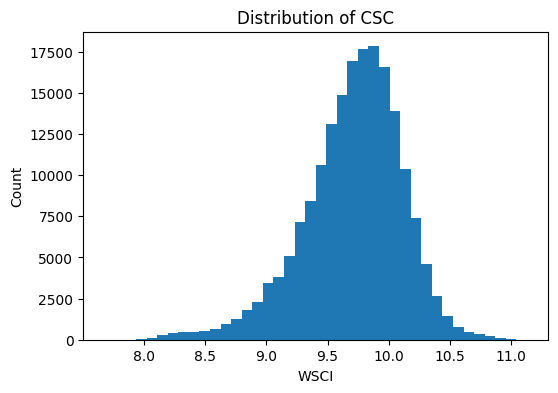

In [7]:
x= "WSCI"
title='Distribution of CSC'

af.histogram(total_df, x, title)

In [37]:
from scipy.stats import pearsonr

print('SD:', pearsonr(total_df['WSCI'], total_df['csc']))

SD: PearsonRResult(statistic=np.float64(0.5955667950862698), pvalue=np.float64(0.0))


Text(0, 0.5, 'csc')

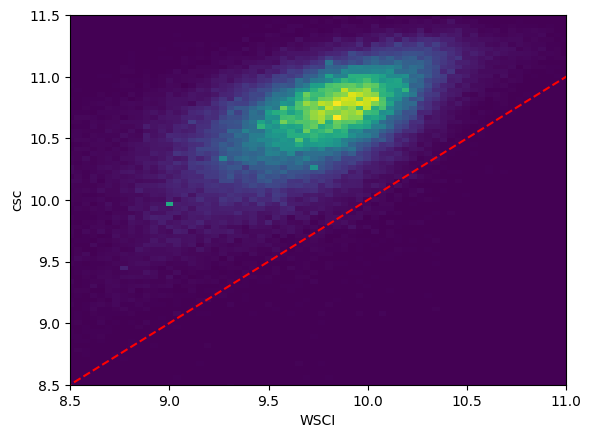

In [52]:
plt.hist2d(total_df['WSCI'], total_df['csc'], bins=90, cmap='viridis')

x = np.linspace(0, 13, 100)

# 1-1 line
y = x

plt.plot(x, y, linestyle='--', label='1:1 line', color='red')

plt.xlim(8.5, 11)
plt.ylim(8.5,11.5)
plt.xlabel('WSCI')
plt.ylabel('csc')

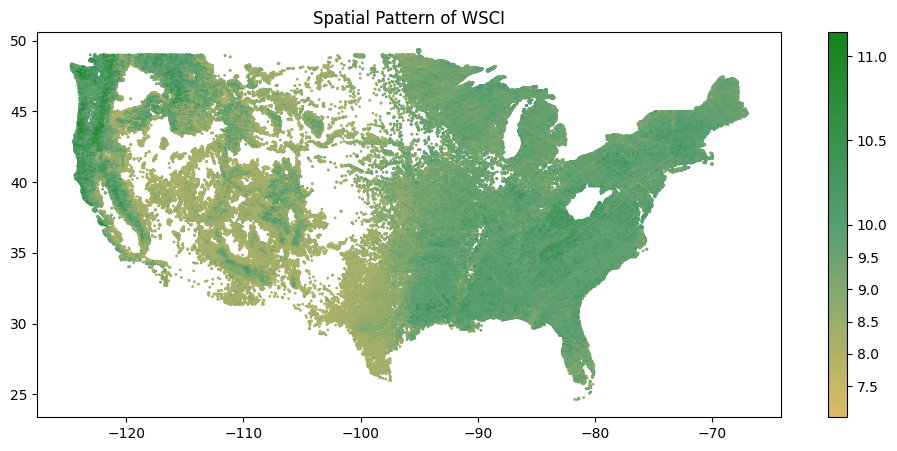

In [51]:
npp_value = 'WSCI'
title = f"Spatial Pattern of {npp_value}"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#DCBC63", "#559E73", "#148418"]  # pink, zero, positive
)

af.spatial_scatter(df["lon"], df["lat"], df[npp_value], title, cmap, vcenter=10)

In [ ]:
sd_df=pd.read_csv('data/final/sd_df.csv')
sd_df = sd_df[sd_df['WSCI'] >= -100]


In [ ]:
plt.plot(sd_df['CHELSA_BIO_Annual_Mean_Temperature'], sd_df['CHELSA_BIO_Annual_Precipitation'])

,PID,CHELSA_BIO_Annual_Mean_Temperature,CHELSA_BIO_Annual_Precipitation,CHELSA_BIO_Precipitation_Seasonality,CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km,SG_SOC_Content_015cm,EsaCci_BurntAreasProbability,EarthEnvTopoMed_Elevation,EarthEnvTopoMed_Slope,SG_Depth_to_bedrock,...,Shannon Diversity,Simpson's Index,transformed npp,WSCI,lat,lon,BHAGE,managed,ownership,biome
0,1_32_13_80818_1,39.433038,404.598144,39.003315,21.217440,32.522411,0.0,2396.5,9.143417,199.999527,...,0.913943,0.550000,0.414486,8.441968,41.673533,-118.744119,125.0,0.0,blm,Xeric shrublands
1,1_32_13_80818_1,39.433038,404.598144,39.003315,21.217440,32.522411,0.0,2396.5,9.143417,199.999527,...,0.913943,0.550000,0.414486,8.441968,41.673533,-118.744119,105.0,0.0,blm,Xeric shrublands
2,1_32_13_80818_1,39.433038,404.598144,39.003315,21.217440,32.522411,0.0,2396.5,9.143417,199.999527,...,0.913943,0.550000,0.414486,8.441968,41.673533,-118.744119,80.0,0.0,blm,Xeric shrublands
3,1_32_13_80818_1,39.433038,404.598144,39.003315,21.217440,32.522411,0.0,2396.5,9.143417,199.999527,...,0.913943,0.550000,0.414486,8.441968,41.673533,-118.744119,134.0,0.0,blm,Xeric shrublands
4,1_32_13_80818_1,39.433038,404.598144,39.003315,21.217440,32.522411,0.0,2396.5,9.143417,199.999527,...,0.913943,0.550000,0.414486,8.441968,41.673533,-118.744119,114.0,0.0,blm,Xeric shrublands
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103527,5_30_93_95196_1,21.533151,374.974945,55.499992,22.301609,16.609741,0.0,2083.5,6.630051,199.937820,...,0.632369,0.363285,0.541404,9.626113,45.905850,-112.611713,85.0,0.0,national_forest,Temperate conifer forests
103528,5_30_93_95196_1,21.533151,374.974945,55.499992,22.301609,16.609741,0.0,2083.5,6.630051,199.937820,...,0.632369,0.363285,0.541404,9.626113,45.905850,-112.611713,110.0,0.0,national_forest,Temperate conifer forests
103529,5_30_93_95196_1,21.533151,374.974945,55.499992,22.301609,16.609741,0.0,2083.5,6.630051,199.937820,...,0.632369,0.363285,0.541404,9.626113,45.905850,-112.611713,120.0,0.0,national_forest,Temperate conifer forests
103530,5_30_93_95196_1,21.533151,374.974945,55.499992,22.301609,16.609741,0.0,2083.5,6.630051,199.937820,...,0.632369,0.363285,0.541404,9.626113,45.905850,-112.611713,145.0,0.0,national_forest,Temperate conifer forests


In [12]:
sd_df.columns

Index(['PID', 'CHELSA_BIO_Annual_Mean_Temperature',
       'CHELSA_BIO_Annual_Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km',
       'SG_SOC_Content_015cm', 'EsaCci_BurntAreasProbability',
       'EarthEnvTopoMed_Elevation', 'EarthEnvTopoMed_Slope',
       'SG_Depth_to_bedrock', 'EarthEnvTopoMed_Northness', 'Species Richness',
       'Shannon Diversity', 'Simpson's Index', 'transformed npp', 'WSCI',
       'lat', 'lon', 'BHAGE', 'managed', 'ownership', 'biome'],
      dtype='str')

Text(0, 0.5, 'transformed npp')

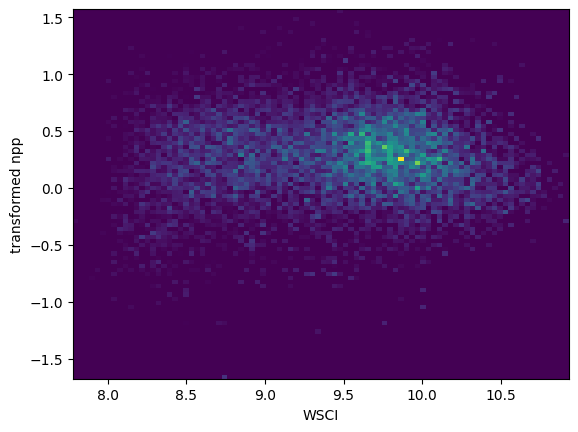

In [14]:
plt.hist2d(sd_df['WSCI'], sd_df['transformed npp'], bins=90, cmap='viridis')

# x = np.linspace(0, 13, 100)

# # 1-1 line
# y = x

# plt.plot(x, y, linestyle='--', label='1:1 line', color='red')

# plt.xlim(8.5, 11)
# plt.ylim(8.5,11.5)
plt.xlabel('WSCI')
plt.ylabel('transformed npp')

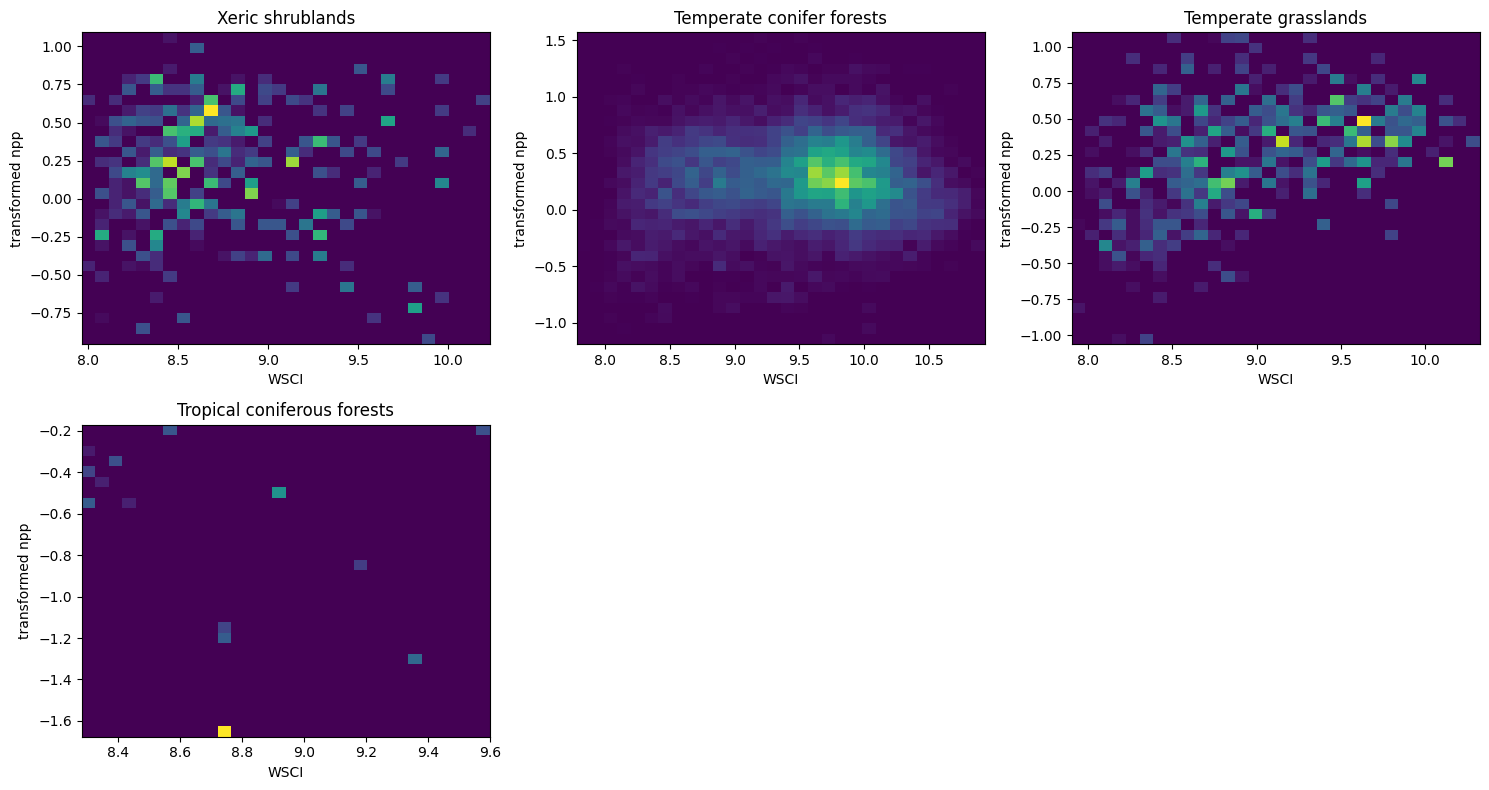

In [16]:
import matplotlib.pyplot as plt
import math

biomes = sd_df['biome'].dropna().unique()
n = len(biomes)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, biome in enumerate(biomes):
    subset = sd_df[sd_df['biome'] == biome]
    axes[i].hist2d(subset['WSCI'], subset['transformed npp'], bins=30, cmap='viridis')
    axes[i].set_title(biome)
    axes[i].set_xlabel('WSCI')
    axes[i].set_ylabel('transformed npp')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
fd_df=pd.read_csv('data/final/fd_df.csv')
fd_df = fd_df[fd_df['WSCI'] >= -100]

In [91]:
fd_df.columns

Index(['PID', 'Raos_Q', 'Functional_Evenness', 'Mean Pairwise D',
       'CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km',
       'SG_SOC_Content_015cm', 'EsaCci_BurntAreasProbability',
       'EarthEnvTopoMed_Elevation', 'EarthEnvTopoMed_Slope',
       'SG_Depth_to_bedrock', 'EarthEnvTopoMed_Northness', 'BHAGE', 'managed',
       'ownership', 'biome', 'transformed npp', 'lat_x', 'lon_x', 'BHAGE_x',
       'managed_x', 'ownership_x', 'biome_x', 'WSCI', 'lat_y', 'lon_y',
       'BHAGE_y', 'managed_y', 'ownership_y', 'biome_y'],
      dtype='str')

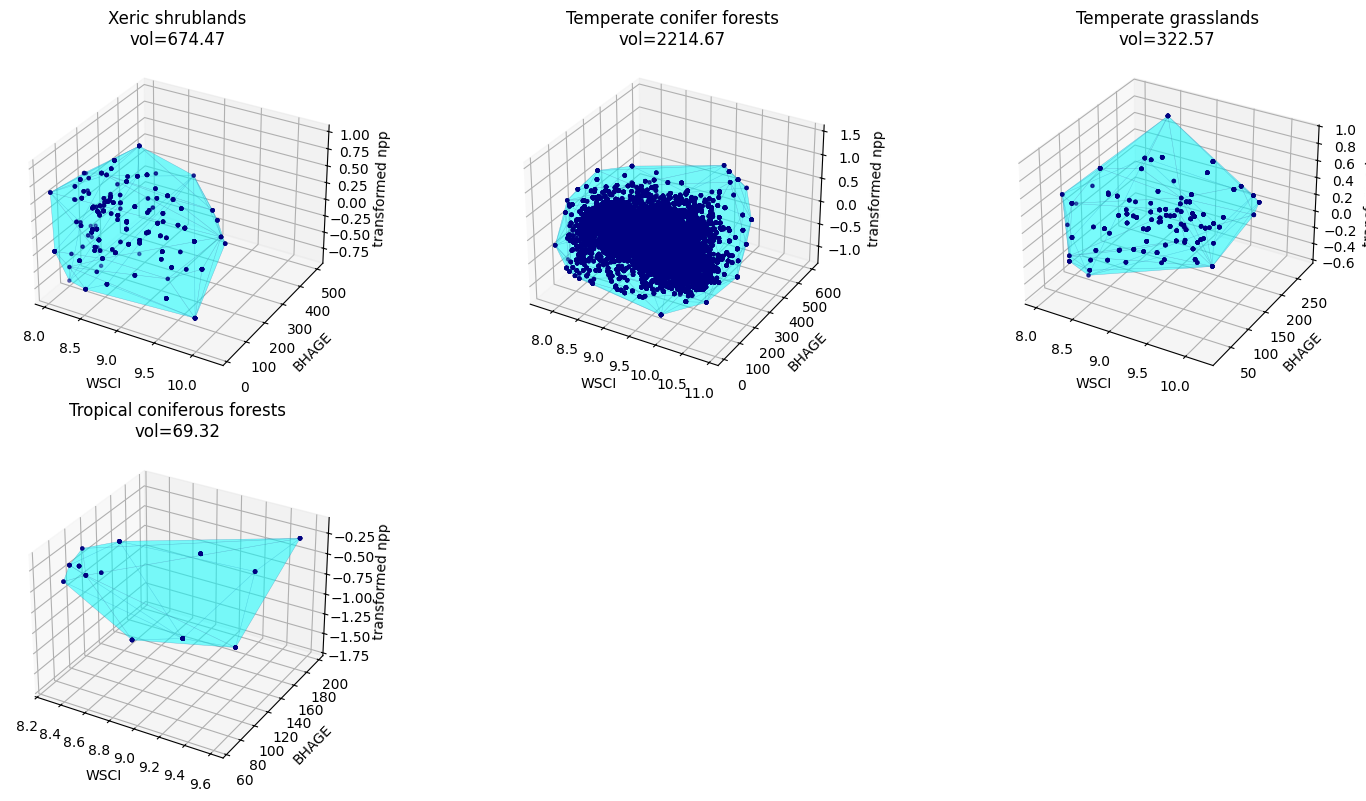

In [93]:
import matplotlib.pyplot as plt
import math
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

biomes = fd_df['biome_y'].dropna().unique()
n = len(biomes)
cols = 3
rows = math.ceil(n / cols)

fig = plt.figure(figsize=(cols * 5, rows * 4))

for i, biome in enumerate(biomes):
    subset = fd_df[fd_df['biome_y'] == biome][['WSCI', 'BHAGE', 'transformed npp',]].dropna()
    ax = fig.add_subplot(rows, cols, i + 1, projection='3d')

    if len(subset) < 4:  # need at least 4 points for a 3D hull
        ax.set_title(f'{biome} (too few points)')
        continue

    points = subset.values
    hull = ConvexHull(points)

    # Draw hull faces
    verts = [points[simplex] for simplex in hull.simplices]
    poly = Poly3DCollection(verts, alpha=0.3, facecolor='cyan', edgecolor='steelblue', linewidth=0.3)
    ax.add_collection3d(poly)

    # Scatter the original points on top
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=5, alpha=0.5, color='navy')

    ax.set_title(f'{biome}\nvol={hull.volume:.2f}')
    ax.set_xlabel('WSCI')
    ax.set_ylabel('BHAGE')
    ax.set_zlabel('transformed npp')

plt.tight_layout()
plt.show()

In [9]:
total_df['group'] = pd.qcut(total_df['WSCI'], q=3, labels=['low', 'mid', 'high'])

In [10]:
total_df

,PID,lat,lon,BHAGE,managed,ownership,biome,WSCI,Unnamed: 0,csc,group
0,1_32_3_523_423,36.139489,-115.548198,NaN,0.0,national_forest,Xeric shrublands,9.278346,438,9.706334,low
1,1_32_3_521_423,36.139920,-115.662665,NaN,0.0,national_forest,Xeric shrublands,8.190137,469,9.794741,low
2,1_32_3_85010_1,36.154960,-115.589376,NaN,0.0,national_forest,Xeric shrublands,9.214615,503,9.837856,low
3,1_32_3_83788_1,36.158003,-115.640089,NaN,0.0,national_forest,Xeric shrublands,8.902037,528,9.708102,low
4,1_32_3_487_423,36.180257,-115.724253,NaN,0.0,national_forest,Xeric shrublands,8.195803,597,9.804961,low
...,...,...,...,...,...,...,...,...,...,...,...
187129,1_19_5_20135_1,43.482715,-91.472034,NaN,1.0,other,Temperate broadleaf forests,8.924268,23523432,10.813293,low
187130,1_19_5_6_301,43.490000,-91.530000,NaN,1.0,other,Temperate broadleaf forests,9.917923,23523667,10.563380,high
187131,1_19_5_12_301,43.490000,-91.420000,NaN,0.0,other,Temperate broadleaf forests,10.017304,23523713,10.826653,high
187132,1_19_5_20090_1,43.490491,-91.400523,NaN,0.0,other,Temperate broadleaf forests,9.925303,23523748,10.839954,high
